## Introduction

In this tutorial, we demonstrate how to extract the outputs of learned cellular dynamics fro TIGON. Here we use EMT dataset as an example.  


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

import sys
sys.path.append('../')
from utility import *
from selex import *



In [5]:
args = create_args()

In [2]:
df=pd.read_csv(f'../doxycol/doxycol10_2d/cleaned.csv')[:10000]

In [3]:
X=np.load(f'../doxycol/doxycol10_2d/descriptor.npz')['descriptor'][:10000]

In [4]:
count=np.load(f'../doxycol/doxycol10_2d/descriptor.npz')['counts'][:10000]

In [6]:
survivors=pd.read_csv(f'../doxycol//survivors.csv')

In [7]:
def all_t_process(df,X,count,survivors,time,n_componets,k):#(time,name,dir,k,device,n_componets):
    #survivors=pd.read_csv(f'{dir}/survivors.csv')
    survivors = survivors.rename(columns={"sequence": "Sequence"})
    survivors = survivors.rename(columns={"count": "Count"})
    survivors=survivors['Sequence'].to_list()
    data=[]
    extra=[]
    pca = PCA(n_components=n_componets)
    for t in time:
        #df=pd.read_csv(f'{dir}/{name}{(t):02d}_2d/cleaned.csv')
        #X=np.load(f'{dir}/{name}{(t):02d}_2d/descriptor.npz')['descriptor']
        #count=np.load(f'{dir}/{name}{(t):02d}_2d/descriptor.npz')['counts']
        X_reduced = pca.fit_transform(X)
        dist,ind,grid=knn_to_grid(df,survivors,X_reduced,k)
        data.append(torch.from_numpy(grid).type(torch.float32).to(device))
        mean=np.mean(count[ind],axis=1)
        extra.append(mean/np.sum(mean))
    return data,extra

In [8]:
torch.enable_grad()
random.seed(args.seed)
torch.manual_seed(args.seed)

device = torch.device('cuda:' + str(args.gpu)
                        if torch.cuda.is_available() else 'cpu')
# load dataset
integral_time = args.timepoints
data_train,count_train=all_t_process(df,X,count,survivors,integral_time,args.n_componets,args.k)

time_pts = range(len(data_train))
leave_1_out = []
train_time = [x for i,x in enumerate(time_pts) if i!=leave_1_out]


# model
func = UOT(in_out_dim=data_train[0].shape[1], hidden_dim=args.hidden_dim,n_hiddens=args.n_hiddens,activation=args.activation).to(device)

# load trained networks
if args.save_dir is not None:
    if not os.path.exists(args.save_dir):
        os.makedirs(args.save_dir)
    ckpt_path = os.path.join(args.save_dir, 'ckpt_EMT.pth')
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path,map_location=torch.device('cpu'))
        func.load_state_dict(checkpoint['func_state_dict'])
        print('Loaded ckpt from {}'.format(ckpt_path))


### Generate the plot of regulatory matrix
Plot avergae regulatory matrices of cells (z_t) at time (time_pt).

Here we use first time points as an examples

In [9]:
from importlib.metadata import version

print("matplotlib:", version("matplotlib"))
print("matplotlib-inline:", version("matplotlib-inline"))
print("ipython:", version("ipython"))

matplotlib: 3.10.9
matplotlib-inline: 0.2.2
ipython: 8.37.0


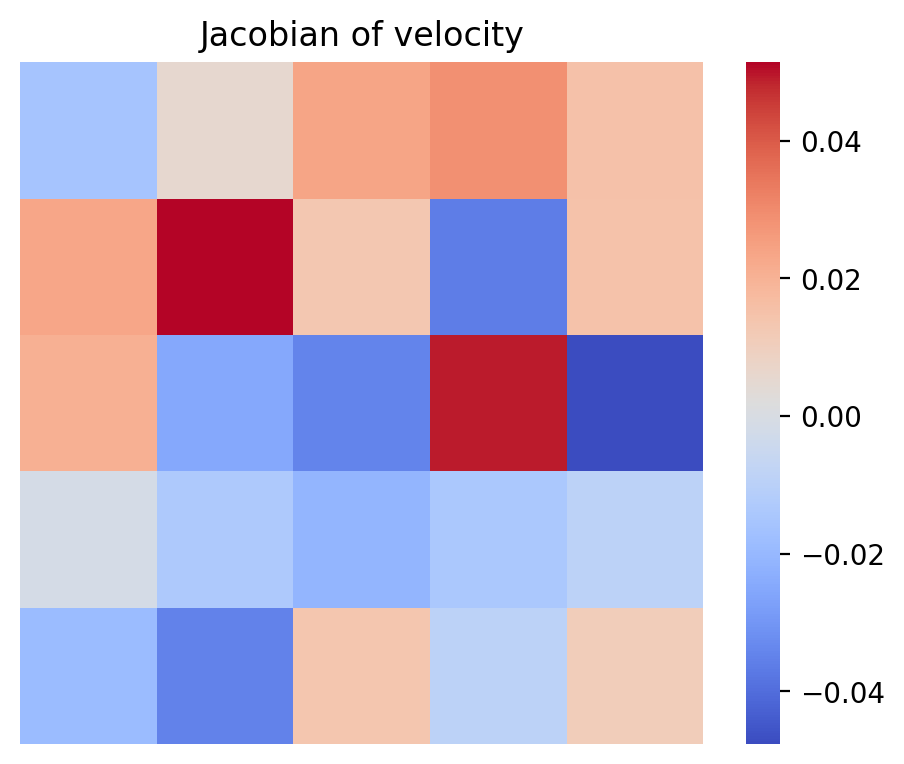

In [10]:
time_pt = 0
z_t = data_train[time_pt]
plot_jac_v(func,z_t,time_pt,'Average_jac_d0.pdf',['UMAP1','UMAP1','UMAP1'],args,device)

### Generate the plot of gradient of growth
Plot avergae gradients of g of cells (z_t) at time (time_pt).

Here we use first time points as an examples

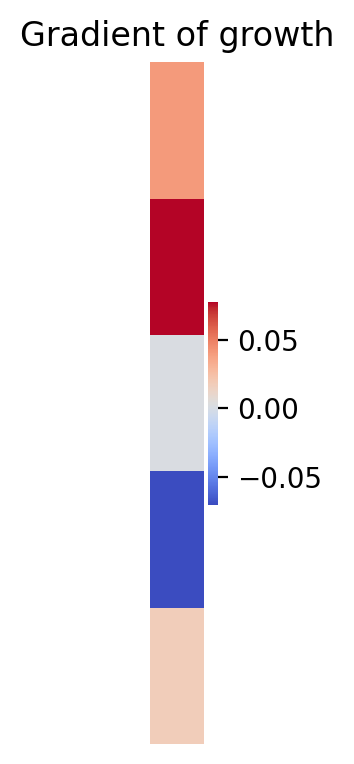

In [11]:
time_pt = 0
z_t = data_train[time_pt]
plot_grad_g(func,z_t,time_pt,'Average_grad_d0.pdf',['UMAP1','UMAP1','UMAP1'],args,device)

### Generate the plot of trajecotry
Plot 3-dmensional plot of inferred trajectories of 20 cells

In [12]:
plot_3d(func,data_train,train_time,integral_time,args,device)

TypeError: plot_3d() missing 1 required positional argument: 'device'